In [2]:
from dotenv import load_dotenv
import typer
import kagglehub
import pandas as pd
import seaborn as sns

c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv(r'..\data\raw\dataset.csv')

In [4]:
df.shape

(1000000, 4)

In [5]:
df.head()

,subreddit,body,controversiality,score
0,gameofthrones,Your submission has been automatically removed...,0,1
1,aww,"Dont squeeze her with you massive hand, you me...",0,19
2,gaming,It's pretty well known and it was a paid produ...,0,3
3,news,You know we have laws against that currently c...,0,10
4,politics,"Yes, there is a difference between gentle supp...",0,1


<Axes: xlabel='controversiality', ylabel='count'>

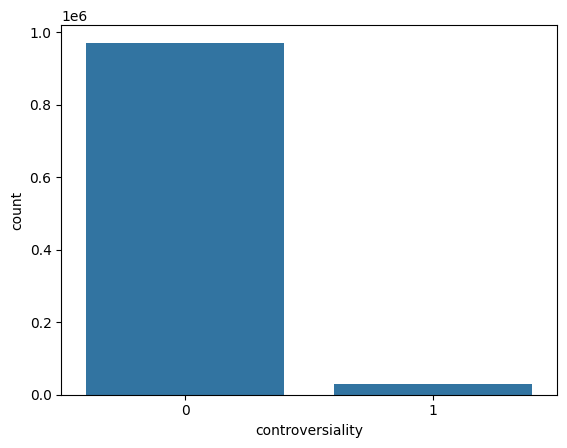

In [10]:
sns.barplot(df['controversiality'].value_counts())

In [31]:
df.rename(columns={'score': 'upvotes'}, inplace=True)

In [32]:
df.head()

,subreddit,body,controversiality,upvotes
0,gameofthrones,Your submission has been automatically removed...,0,1
1,aww,"Dont squeeze her with you massive hand, you me...",0,19
2,gaming,It's pretty well known and it was a paid produ...,0,3
3,news,You know we have laws against that currently c...,0,10
4,politics,"Yes, there is a difference between gentle supp...",0,1


In [29]:
sub_rdf = df[~df['body'].str.contains('Your submission has been automatically removed')]

In [30]:
sub_rdf

,subreddit,body,controversiality,score
1,aww,"Dont squeeze her with you massive hand, you me...",0,19
2,gaming,It's pretty well known and it was a paid produ...,0,3
3,news,You know we have laws against that currently c...,0,10
4,politics,"Yes, there is a difference between gentle supp...",0,1
5,dankmemes,Please let this become a meme. I want some Dar...,0,2
...,...,...,...,...
999995,Pikabu,И ла и нет. Если жопа будет слишком сзади поте...,0,1
999996,Pikabu,"Исходя из этого, я тогда 3 раза все лайки инте...",0,2
999997,Pikabu,Человек из лиги ЛГБТ поди и не раз...,0,1
999998,Pikabu,"С Пикабу ушел,не для того что бы скрины читать",0,-5


In [34]:
sub_rdf.info()

<class 'pandas.DataFrame'>
Index: 999017 entries, 1 to 999999
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   subreddit         999017 non-null  str  
 1   body              999017 non-null  str  
 2   controversiality  999017 non-null  int64
 3   score             999017 non-null  int64
dtypes: int64(2), str(2)
memory usage: 38.1 MB


In [37]:
sub_rdf['controversiality'].value_counts()/ sub_rdf.shape[0] * 100

controversiality
0    97.038789
1     2.961211
Name: count, dtype: float64

In [47]:
from langdetect import detect, DetectorFactory, LangDetectException
def detect_language_single(text: str) -> str:
    if not isinstance(text, str) or len(text.strip()) < 10:
        return 'unknown'
    try:
        return detect(text)
    except LangDetectException:
        return 'unknown'

In [ ]:
from loguru import logger


def run_language_eda(df: pd.DataFrame) -> (pd.DataFrame, pd.DataFrame):
    
    # WHY min()? If dataset < 10K rows, don't crash
    # sample_df = df['body'].dropna().sample(
    #     min(len(df), len(df)), 
    #     random_state=42          # reproducible sample
    # )
    
    sample_df = df

    # Detect language for each row in sample
    langs = sample_df.apply(detect_language_single)
    
    # --- Distribution ---
    lang_counts = langs.value_counts()
    lang_pct    = langs.value_counts(normalize=True) * 100
    
    lang_df = pd.DataFrame({
        'language': lang_counts.index,
        'count'   : lang_counts.values,
        'percent' : lang_pct.values.round(2)
    })
    
    return lang_df, pd.DataFrame({'body': sample_df, 'langs': langs})

In [ ]:
import re

def clean_text(text: str) -> str | None:
    if not isinstance(text, str):
        return None
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove Reddit-specific formatting
    text = re.sub(r'\[.*?\]\(.*?\)', '', text)  # [text](url) markdown links
    text = re.sub(r'&gt;.*?\n', '', text)        # quoted text (>)
    text = re.sub(r'r/\w+|u/\w+', '', text)     # subreddit/user mentions
    
    # Remove mentions, hashtags
    text = re.sub(r'[@#]\w+', '', text)
    
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Discard if too short after cleaning
    # WHY 10? Less than 10 chars = no sentiment signal
    return text if len(text) >= 10 else None

In [108]:
sub_rdf['body'] = sub_rdf['body'].apply(clean_text)

In [118]:
sub_rdf['body'].head()

1    Dont squeeze her with you massive hand, you me...
2    It's pretty well known and it was a paid produ...
3    You know we have laws against that currently c...
4    Yes, there is a difference between gentle supp...
5    Please let this become a meme. I want some Dar...
Name: body, dtype: str

In [120]:
import emoji

sub_rdf['body'] = sub_rdf['body'].apply(lambda x: emoji.demojize(str(x)).replace(":", ''))

In [121]:
lang_dist, sample_df = run_language_eda(sub_rdf)

In [129]:
lang_dist

,language,count,percent
0,en,9324,93.24
1,ru,232,2.32
2,af,51,0.51
3,no,36,0.36
4,fr,35,0.35
5,nl,33,0.33
6,et,24,0.24
7,de,24,0.24
8,cy,24,0.24
9,tl,23,0.23


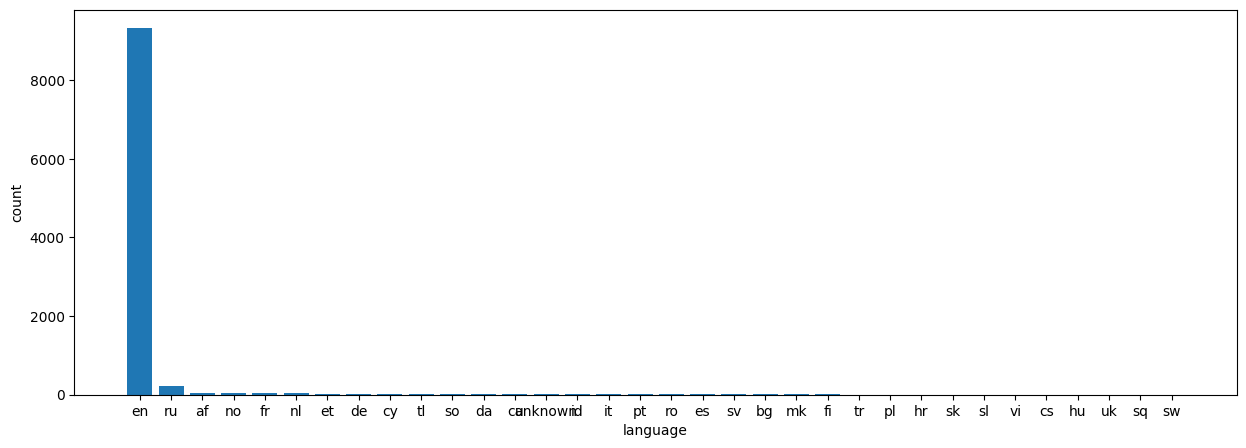

In [123]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
plt.bar(lang_dist['language'], lang_dist["count"])
plt.xlabel("language")
plt.ylabel("count")
plt.show()

In [148]:
mask = sample_df['langs'] == 'ru'

In [154]:
sample_df[mask]

,body,langs
803501,"В такие колбы запечатывали цезий-137, если нет...",ru
274183,"так в том и прикол, что ребёнку в этом возраст...",ru
905808,"Чувак, ты из какого населенного пункта, где да...",ru
931231,Последние секунды битвы достойны экранизации. ...,ru
744719,"лучше такой, стене точно пиздец будет [",ru
...,...,...
983070,Будет уже поздно. У админа встанет,ru
394315,"Что там дешевле в 2+ раза? Другой бренд, может...",ru
898521,"Перевод - Что ты хочешь получить на рождество,...",ru
991762,"Тут боятся не столько политику, сколько правил...",ru


In [ ]:
sample_df.loc[[803501, 394315, 991762, 886902, 983070]]

,body,langs
803501,"В такие колбы запечатывали цезий-137, если нет...",ru
394315,"Что там дешевле в 2+ раза? Другой бренд, может...",ru


In [159]:
trdf = pd.read_csv("../data/processed/processed.csv")

In [170]:
trdf.loc[[23], ['body', 'translated_body']].tail().values

array([['Не отменяет того факта, что человек так проработает максимум минут 30, если постарается',
        "Doesn't change the fact that a man would work like this for 30 minutes at most if he tried."]],
      dtype=object)